# 01 - Data audit

**Goal:** understand the dataset *before* training. This notebook only reads and reports. It never copies, deletes or changes an image.

The heavy code lives in `src/` (`audit.py`, `audit_plots.py`). This notebook calls it and explains the results.

## 1. Setup
Make sure Python runs from the project root so that `from src...` imports and relative paths in the config work.

In [8]:
import os
import sys

# If the notebook is opened from notebooks/, move to the project root.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: d:\maktab\145\tvc-clean


In [9]:
from pathlib import Path
import pandas as pd
from IPython.display import Image as show_image
from src.utils import load_config, set_seed, get_device
from src.audit import print_summary

cfg = load_config()
set_seed(cfg["seed"])
print("seed:", cfg["seed"], "| device:", get_device())

seed: 42 | device: cuda


## 2. Load the file table
`python -m src.audit` scanned every file and saved one row per file. Here we only read that table.

In [10]:
reports = Path(cfg["paths"]["reports_dir"])
df = pd.read_csv(reports / "audit_files.csv")
print("Total files scanned:", len(df))
df.head()

Total files scanned: 4360


,split,class,path,extension,readable,width,height,mode,error
0,train,ambulance,train/ambulance/195939523.jpg,.jpg,True,307,366,RGB,NaN
1,train,ambulance,train/ambulance/198727855.jpg,.jpg,True,328,365,RGB,NaN
2,train,ambulance,train/ambulance/199031396.jpg,.jpg,True,253,333,RGB,NaN
3,train,ambulance,train/ambulance/199587392.jpg,.jpg,True,290,326,RGB,NaN
4,train,ambulance,train/ambulance/199659807.jpg,.jpg,True,286,328,RGB,NaN


## 3. Summary
Counts per class and split, unreadable files, image sizes and color modes.

In [11]:
print_summary(df)


=== Images per class and split ===
split      test  train  unclean
class                          
ambulance    50    219      157
autobus      50    245      226
kamyun       50    250      246
kamyunet     50    238      221
minibus      50    230      185
neysan        0      0      250
savari       50    250      250
taxi         50    250      243
vanet        50    250      250

=== Class folders found in each split ===
train -> ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
test -> ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
unclean -> ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'neysan', 'savari', 'taxi', 'vanet']

=== Files that could not be read as images: 0 ===

=== Image size statistics (pixels) ===
        width  height
count  4360.0  4360.0
mean    253.8   314.1
std      69.7    94.8
min     117.0   156.0
25%     195.0   252.0
50%     248.0   276.0
75%     302.0   369.0
max     6

## 4. Figures

### Images per class and split
Look for rare classes (class imbalance) and for class names that exist in one split but not in another.

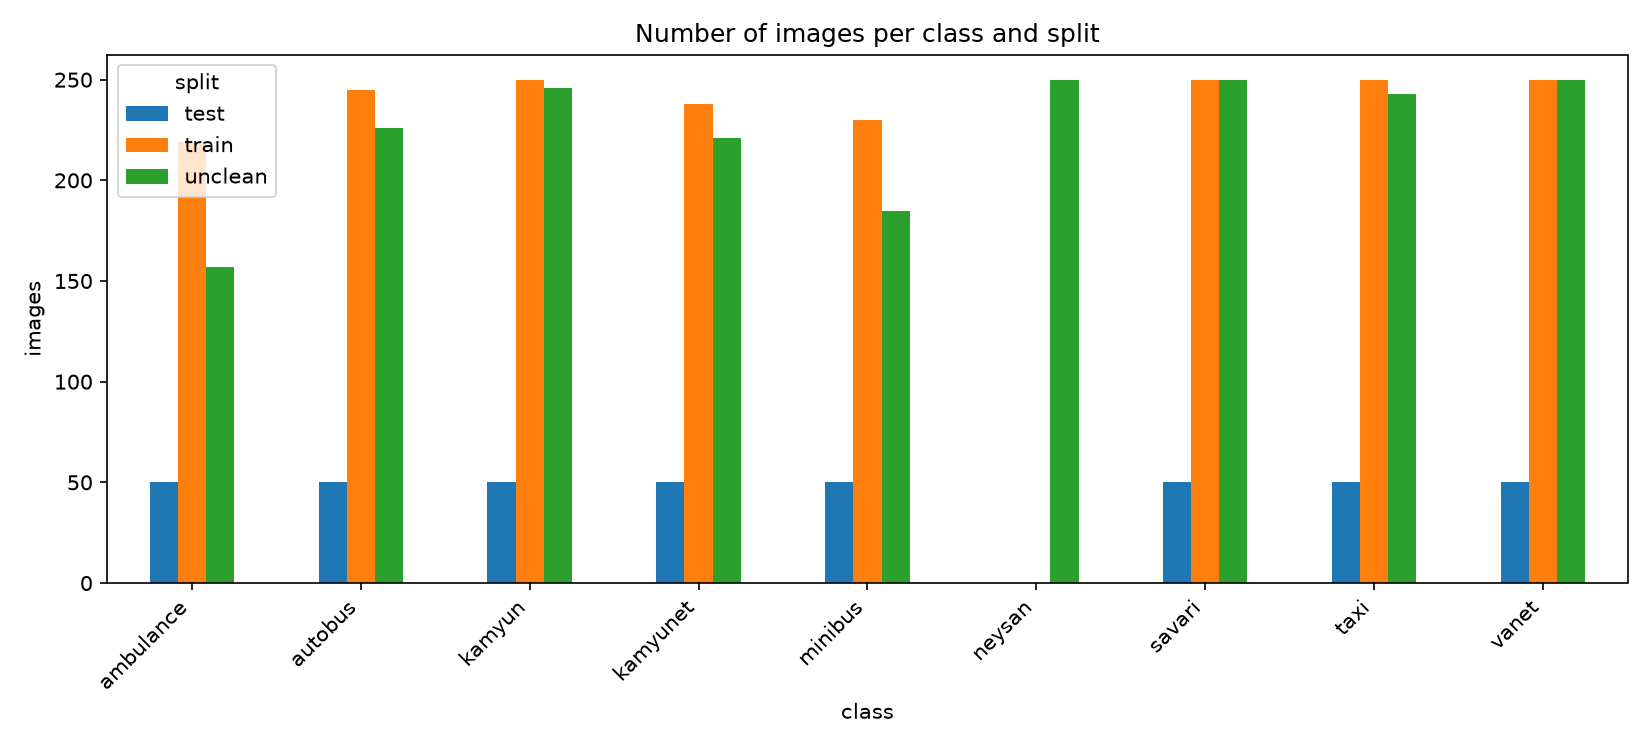

In [12]:
show_image(filename=str(reports / "figures" / "audit_class_counts.png"))

### Image sizes
Images have different sizes, so every image will be resized to a fixed size before training.

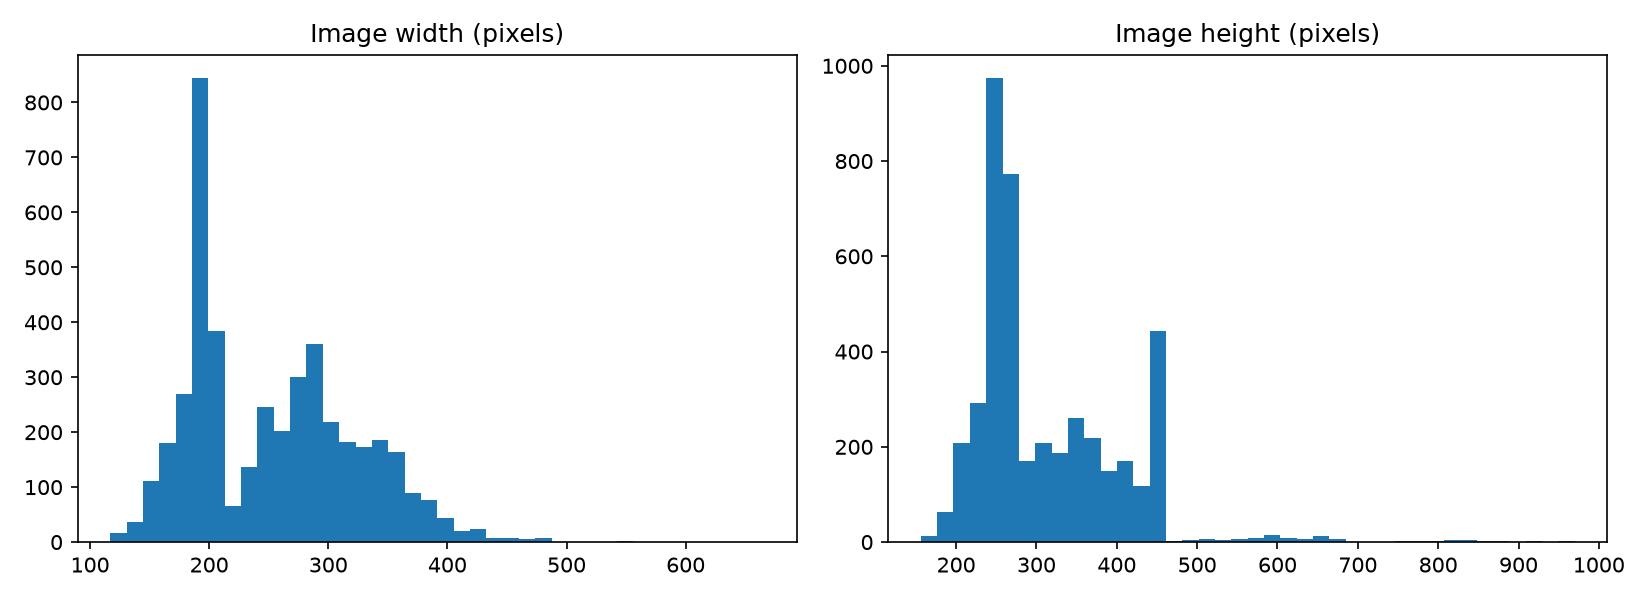

In [13]:
show_image(filename=str(reports / "figures" / "audit_image_sizes.png"))

### 12 random training images
A quick visual check: do the class names match what you see?

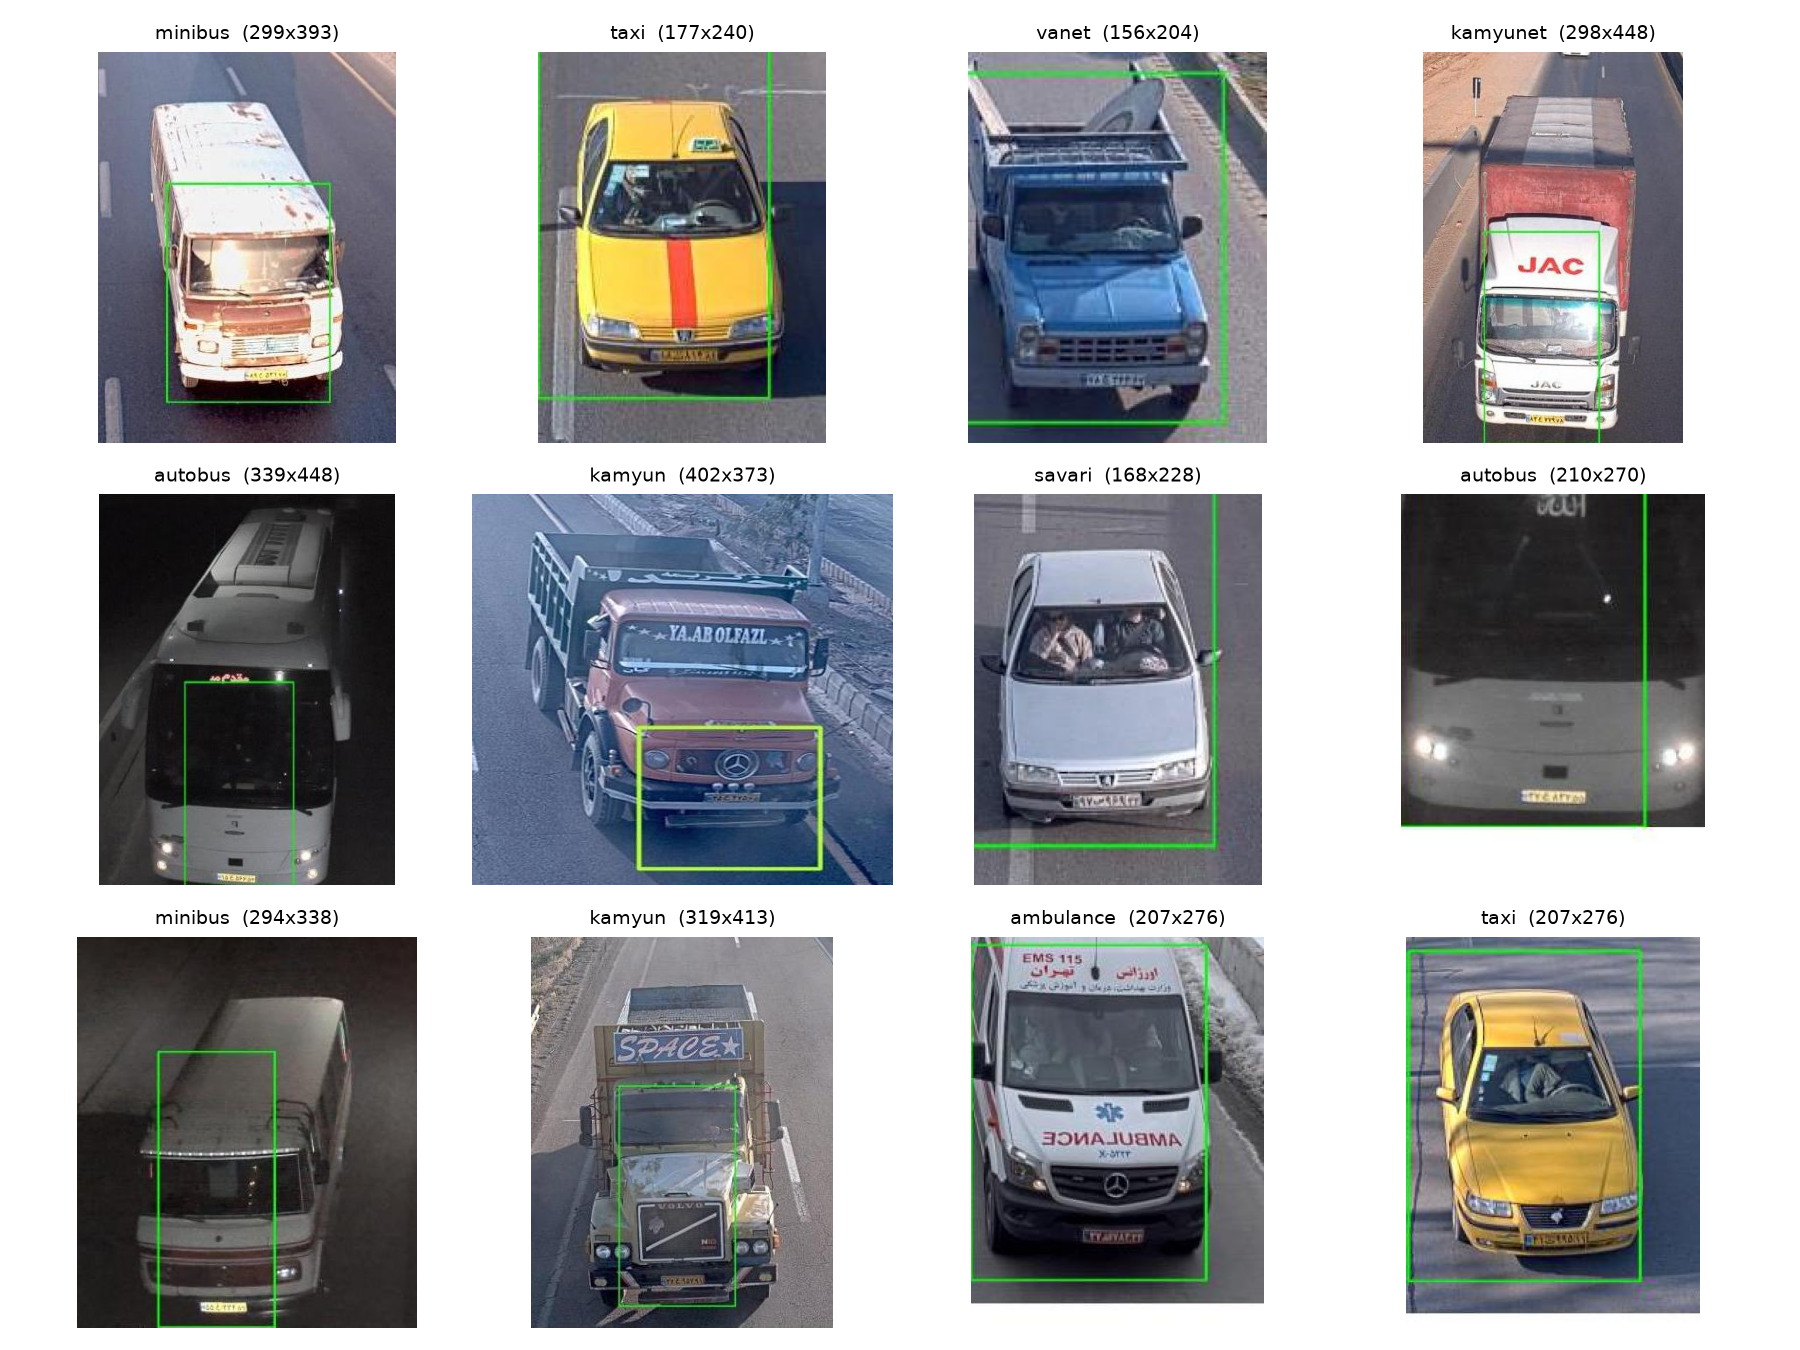

In [14]:
show_image(filename=str(reports / "figures" / "audit_samples.png"))

## 5. Findings

**Dataset size.** There are 4,360 images in total: 1,932 in `train`, 400 in `test` and 2,028 in `unclean`. Every file opened without errors and every image is RGB.

**Class balance.** `test` is perfectly balanced (50 images per class). `train` is almost balanced: the 8 classes have between 219 (`ambulance`) and 250 images, so the largest class is only about 1.14 times the smallest. The imbalance is mild. `ambulance` is also the rarest class in `unclean` (157 images).

**Class names.** `train` and `test` contain the same 8 classes. `unclean` contains these 8 classes plus a ninth class, `neysan` (250 images), which does not exist in `train` or `test`. A model trained on `train` has never seen it, so `neysan` is an unseen-class case. It must stay out of training and validation, and we will handle it later with a confidence threshold and a `needs_review` decision.

**The `unclean` folder.** It holds 2,028 images of the 8 known classes. It may contain duplicates of `train` or `test` images and wrong labels, so it must not be mixed into training before it is checked. This is the next step.

**Image sizes.** Widths go from 117 to 666 px (median 248) and heights from 156 to 970 px (median 276). Most images are portrait (taller than wide). The width histogram has a sharp peak near 190-200 px and a second, wider group around 250-350 px, which suggests the images come from more than one source or crop style. Most heights stop near 460 px, and only a few images are taller than 500 px. No image is tiny (smallest side is 117 px). Plan: resize every image to 224x224. Because most images are portrait, direct resizing stretches them slightly; I will keep this simple for now and not crop, so that parts of the vehicle are not cut off.

**Visual check.** All 12 sample images have a green rectangle drawn on the picture itself. The set also mixes daylight images with dark, night-like ones. Risk: the model could learn to use the green box instead of the vehicle. I will watch for this in the error analysis.

**Next step.** Find exact and near-duplicate images, and check whether the same image appears with different labels.

**Next step:** find exact and near-duplicate images, and check whether the same image appears with different labels.